# Reto 4 — Implementación explicada de Deep Q-Learning
## Agente DQN para **Flappy Bird** (`flappy-bird-gymnasium`)

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Ambiente elegido:** `FlappyBird-v0` (entorno de terceros registrado en Gymnasium)

---

### Resumen ejecutivo

Se entrenó un agente **Deep Q-Network (DQN)** para jugar Flappy Bird a partir de un vector de
12 observaciones numéricas. Tras **6 610 episodios (≈ 709 000 pasos de interacción)** el agente
pasó de estrellarse siempre contra el primer tubo a **superar en promedio 27 tubos por episodio**
con la política greedy, contra **0 tubos** de una política aleatoria.

| Métrica (30 episodios de prueba) | Política aleatoria | DQN greedy |
|---|---|---|
| Retorno medio | **−7.74** | **+129.49** |
| Tubos superados (media) | 0.00 | **27.17** |
| Mejor episodio | 0 tubos | **79 tubos** |
| Pasos sobrevividos (media) | 50 | **1 061** |

### ¿Por qué este ambiente?

1. **El estado es continuo**, así que una tabla `Q[s,a]` es literalmente imposible sin discretizar
   artificialmente 12 variables reales. Es exactamente la situación que motiva la aproximación de
   función descrita en la diapositiva 8 del curso.
2. **Es poco usado en clase**, lo que evita duplicar el trabajo de un compañero.
3. La evidencia de aprendizaje es **visual e inmediata**: se puede grabar el episodio y ver al
   agente volando.
4. Solo tiene **2 acciones**, así que la red Q es pequeña y entrena en CPU.

### Fuentes (detalle en la sección 7)

El código **no** se copió de un repositorio único: se escribió siguiendo el pseudocódigo de la
diapositiva 18 del curso, tomando como referencia conceptual el tutorial oficial de PyTorch
*Reinforcement Learning (DQN) Tutorial* y la documentación del paquete `flappy-bird-gymnasium`.
**Adaptaciones propias:** replay buffer vectorizado con NumPy, **Double DQN**, pérdida de Huber,
recorte de gradiente, decaimiento de ε anclado a pasos globales y todo el análisis de resultados.

---
## 0. Instalación e importaciones

`flappy-bird-gymnasium` no viene preinstalado en Colab. La bandera `use_lidar=False` selecciona la
versión de **12 observaciones numéricas** (la alternativa es un LIDAR de 180 rayos, mucho más pesado).

In [1]:
!pip -q install flappy-bird-gymnasium gymnasium torch matplotlib

In [2]:
import os, time, random, json
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")   # permite renderizar sin pantalla (Colab)

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import flappy_bird_gymnasium            # registra "FlappyBird-v0" por efecto de importación
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("gymnasium:", gym.__version__, "| torch:", torch.__version__, "| device:", DEVICE)

gymnasium: 1.3.0 | torch: 2.13.0+cu130 | device: cpu


---
# 1. El ambiente

> *Rúbrica — "Comprensión del ambiente" (20 %): define correctamente estado, acciones, recompensas y terminación.*

## 1.1 Descripción del juego

El agente controla un pájaro que cae por gravedad de forma constante. En cada paso decide si
**aletear** (impulso vertical hacia arriba) o **no hacer nada** (seguir cayendo). El objetivo es
atravesar la mayor cantidad posible de huecos entre pares de tubos.

## 1.2 Espacio de estados: `Box(-1.0, 1.0, (12,))`

La observación es un vector de **12 números reales ya normalizados al rango [−1, 1]**:

| # | Variable | Significado |
|---|---|---|
| 0 | `last_pipe_x` | posición horizontal del **último** tubo (el que ya pasó) |
| 1–2 | `last_pipe_top_y`, `last_pipe_bottom_y` | bordes superior e inferior de ese hueco |
| 3 | `next_pipe_x` | posición horizontal del **siguiente** tubo |
| 4–5 | `next_pipe_top_y`, `next_pipe_bottom_y` | bordes del hueco que debe atravesar **ahora** |
| 6 | `next_next_pipe_x` | posición horizontal del tubo **subsiguiente** |
| 7–8 | `next_next_top_y`, `next_next_bottom_y` | bordes de ese hueco |
| 9 | `player_y` | altura del pájaro |
| 10 | `player_vel_y` | velocidad vertical del pájaro |
| 11 | `player_rot` | rotación del sprite |

**Por qué esto obliga a usar DQN:** son 12 variables continuas. Aunque discretizáramos cada una en
apenas 10 niveles, la tabla tendría $10^{12}$ filas — imposible de almacenar y, peor aún, imposible
de visitar lo suficiente. La red neuronal, en cambio, **generaliza**: dos estados con tubos en
posiciones parecidas producen valores Q parecidos sin necesidad de haberlos visitado.

Nótese además que las variables 10 y 11 (velocidad y rotación) hacen que el estado sea **markoviano**:
sin la velocidad, la observación no bastaría para decidir, porque el mismo `player_y` requiere
acciones distintas según si el pájaro va subiendo o cayendo.

## 1.3 Espacio de acciones: `Discrete(2)`

| Valor | Acción |
|---|---|
| `0` | no hacer nada (dejar caer) |
| `1` | aletear |

## 1.4 Función de recompensa

| Evento | Recompensa |
|---|---|
| Sobrevivir un paso | **+0.1** |
| Atravesar un par de tubos | **+1.0** |
| Chocar (tubo o suelo) | **−1.0** y episodio terminal |
| Estar tocando el techo de la pantalla | **−0.5** por paso |

## 1.5 Condición terminal

- `terminated = True` cuando el pájaro choca con un tubo o con el suelo.
- `truncated`: el ambiente no impone límite propio, así que **se añade un truncamiento a 3 000 pasos**
  para que un agente muy bueno no genere episodios infinitos. Esta distinción es importante:
  un episodio **truncado no es un estado terminal real**, por lo que sí se debe seguir haciendo
  bootstrapping (ver sección 4.2).

In [3]:
env = gym.make("FlappyBird-v0", use_lidar=False)

print("Espacio de observación:", env.observation_space)
print("Espacio de acciones   :", env.action_space)
print("Dimensión del estado  :", env.observation_space.shape[0])
print("Número de acciones    :", env.action_space.n)

obs, info = env.reset(seed=SEED)
print("\nObservación inicial (12 features):")
print(np.round(obs, 3))
print("\ninfo:", info)

Espacio de observación: Box(-1.0, 1.0, (12,), float64)
Espacio de acciones   : Discrete(2)
Dimensión del estado  : 12
Número de acciones    : 2

Observación inicial (12 features):
[ 1.     0.312  0.508  1.     0.     1.     1.     0.     1.     0.477
 -0.9    0.5  ]

info: {'score': 0}


## 1.6 Línea base: agente aleatorio

Antes de entrenar nada, medimos qué tan malo es actuar al azar. Esto da el punto de comparación
honesto para la sección de resultados.

In [4]:
def evaluar(politica, env, n_episodios=30, max_pasos=3000, seed0=10_000):
    """Corre n episodios con una política dada y devuelve retornos, scores y duraciones."""
    retornos, scores, duraciones = [], [], []
    for k in range(n_episodios):
        s, _ = env.reset(seed=seed0 + k)
        s = np.asarray(s, dtype=np.float32)
        total, info = 0.0, {}
        for t in range(max_pasos):
            a = politica(s)
            s, r, terminated, truncated, info = env.step(a)
            s = np.asarray(s, dtype=np.float32)
            total += r
            if terminated or truncated:
                break
        retornos.append(total); scores.append(info.get("score", 0)); duraciones.append(t + 1)
    return np.array(retornos), np.array(scores), np.array(duraciones)


rng = np.random.default_rng(0)
politica_aleatoria = lambda s: int(rng.integers(2))

r_rand, s_rand, l_rand = evaluar(politica_aleatoria, env)
print("AGENTE ALEATORIO (30 episodios)")
print(f"  retorno medio : {r_rand.mean():.2f} ± {r_rand.std():.2f}")
print(f"  tubos medios  : {s_rand.mean():.2f}  (máximo {s_rand.max()})")
print(f"  pasos medios  : {l_rand.mean():.1f}")

AGENTE ALEATORIO (30 episodios)
  retorno medio : -7.74 ± 0.88
  tubos medios  : 0.00  (máximo 0)
  pasos medios  : 50.0


El retorno de **−7.74** merece una explicación, porque a primera vista sorprende que sea tan negativo
si sobrevivir da +0.1: una política aleatoria aletea la mitad de los pasos, lo que hace que el pájaro
**suba y se quede pegado al techo**, acumulando la penalización de −0.5 por paso hasta que aparece
el primer tubo. Es decir, el agente aleatorio no solo no anota: se comporta activamente mal.
Conviene guardar este dato, porque será lo primero que el agente aprenda a corregir.

---
# 2. La red Q

> *Rúbrica — punto 2 de la estructura mínima: ¿cuál es la entrada? ¿cuál es la salida? ¿cuántas capas? ¿por qué esa arquitectura es razonable?*

Siguiendo la diapositiva 10, la red recibe **el estado** y devuelve **un valor Q por acción**:

$$Q(s,\cdot\,;\theta) = \begin{bmatrix} Q(s, \text{no aletear}) \\ Q(s, \text{aletear}) \end{bmatrix}$$

y la acción greedy es $a^{*} = \arg\max_a Q(s,a;\theta)$.

| Capa | Dimensión | Activación |
|---|---|---|
| Entrada | 12 (el vector de observación) | — |
| Oculta 1 | 128 | ReLU |
| Oculta 2 | 128 | ReLU |
| Salida | 2 (un Q por acción) | ninguna |

**Justificación de la arquitectura:**

- **Entrada de 12 y no una imagen.** Se podría haber usado la versión RGB del ambiente y una CNN,
  pero eso multiplicaría el costo de entrenamiento sin aportar nada conceptual: las 12 variables ya
  contienen toda la información relevante del estado.
- **Dos capas de 128.** El mapeo estado → valor es una función suave y de baja dimensión; con 12
  entradas, 128 neuronas dan capacidad de sobra. Se probó también 256 y no mejoró el resultado, solo
  hizo el entrenamiento ~1.6× más lento.
- **Sin activación en la salida.** Los valores Q son retornos esperados y pueden ser negativos
  (chocar da −1) o crecer bastante (un episodio largo acumula muchos +0.1). Una sigmoide o un ReLU
  final destruirían ese rango.
- **Una sola pasada evalúa las 2 acciones**, que es justo la ventaja señalada en la diapositiva 10.

In [5]:
class QNetwork(nn.Module):
    """Aproximador Q(s, ·; theta): estado -> vector de valores Q, uno por acción."""

    def __init__(self, n_obs, n_act, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_act),          # sin activación final
        )

    def forward(self, x):
        return self.net(x)


N_OBS = env.observation_space.shape[0]
N_ACT = env.action_space.n

demo = QNetwork(N_OBS, N_ACT)
print(demo)
print("\nParámetros entrenables:", sum(p.numel() for p in demo.parameters()))
print("Salida para el estado inicial:",
      demo(torch.as_tensor(obs, dtype=torch.float32)).detach().numpy().round(4))

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Parámetros entrenables: 18306
Salida para el estado inicial: [-0.0361  0.0658]


---
# 3. Componentes de DQN

> *Rúbrica — "Explicación del algoritmo" (25 %): replay buffer, target network, loss y exploración.*

## 3.1 Replay buffer

Como explica la diapositiva 13, si entrenáramos con cada transición apenas ocurre, los mini-lotes
estarían formados por estados casi idénticos ($S_t \to S_{t+1} \to S_{t+2}$), lo que viola la
suposición de datos i.i.d. del descenso de gradiente y desestabiliza el entrenamiento.

El buffer almacena tuplas $(s, a, r, s', done)$ y el entrenamiento toma **mini-lotes aleatorios** de él.
Beneficios: rompe la correlación temporal, reutiliza cada experiencia muchas veces y estabiliza el
aprendizaje.

**Adaptación propia:** en lugar de un `deque` de tuplas de Python (lo habitual en los tutoriales),
se usan **cinco arreglos NumPy preasignados** con un índice circular. El muestreo se vuelve una
indexación vectorizada, lo que evita el costo de convertir listas de tuplas a tensores en cada paso.

**Nota sobre `done`:** se guarda únicamente `terminated`, **no** `terminated or truncated`. Si el
episodio se cortó por el límite de 3 000 pasos, el futuro sigue existiendo y hay que hacer
bootstrapping normalmente; tratarlo como terminal le enseñaría a la red que el mundo se acaba
arbitrariamente.

In [6]:
class ReplayBuffer:
    """Memoria de experiencias con arreglos NumPy preasignados e índice circular."""

    def __init__(self, capacidad, n_obs):
        self.cap = capacidad
        self.n = 0     # cuántas transiciones válidas hay
        self.i = 0     # dónde escribir la siguiente
        self.s  = np.zeros((capacidad, n_obs), dtype=np.float32)
        self.a  = np.zeros(capacidad, dtype=np.int64)
        self.r  = np.zeros(capacidad, dtype=np.float32)
        self.s2 = np.zeros((capacidad, n_obs), dtype=np.float32)
        self.d  = np.zeros(capacidad, dtype=np.float32)   # 1.0 si s2 es terminal

    def push(self, s, a, r, s2, d):
        i = self.i
        self.s[i], self.a[i], self.r[i], self.s2[i], self.d[i] = s, a, r, s2, d
        self.i = (i + 1) % self.cap          # sobreescribe lo más viejo
        self.n = min(self.n + 1, self.cap)

    def sample(self, batch):
        idx = np.random.randint(0, self.n, size=batch)
        return (torch.from_numpy(self.s[idx]),  torch.from_numpy(self.a[idx]),
                torch.from_numpy(self.r[idx]),  torch.from_numpy(self.s2[idx]),
                torch.from_numpy(self.d[idx]))

    def __len__(self):
        return self.n

## 3.2 Política ε-greedy

Aunque la tabla se reemplazó por una red, **el dilema exploración–explotación no desaparece**
(diapositiva 17):

$$\epsilon\text{-greedy}: \begin{cases} \text{acción aleatoria} & \text{con probabilidad } \epsilon \\ \arg\max_a Q(s,a;\theta) & \text{con probabilidad } 1-\epsilon \end{cases}$$

**Calendario de decaimiento elegido:** $\epsilon$ baja **linealmente de 1.0 a 0.01 a lo largo de los
primeros 80 000 pasos** y luego se mantiene en 0.01.

¿Por qué lineal y no exponencial? Porque el decaimiento exponencial habitual (`eps *= 0.995` por
episodio) está atado al **número de episodios**, y en Flappy Bird los episodios cambian
drásticamente de longitud: al principio duran 50 pasos y al final más de 1 000. Anclar el
decaimiento al **contador global de pasos** hace que la cantidad de exploración sea predecible
y no dependa de qué tan bueno se vuelva el agente.

¿Por qué un $\epsilon$ final tan bajo (0.01) y no el típico 0.05? Porque en este juego **una sola
acción equivocada mata al agente**. Con $\epsilon = 0.05$, un episodio de 200 pasos contiene unas
10 acciones aleatorias y la probabilidad de sobrevivir se desploma. Volveremos sobre esto en la
sección 5.2, porque incluso 0.01 resultó ser demasiado.

In [7]:
EPS_INICIAL, EPS_FINAL, EPS_PASOS = 1.0, 0.01, 80_000

def epsilon(paso_global):
    """Decaimiento lineal anclado al número de pasos de interacción, no de episodios."""
    frac = min(1.0, paso_global / EPS_PASOS)
    return EPS_INICIAL + frac * (EPS_FINAL - EPS_INICIAL)


def accion_epsilon_greedy(red, estado, eps, n_act):
    if random.random() < eps:
        return int(np.random.randint(n_act))          # EXPLORA
    with torch.no_grad():                             # EXPLOTA
        return int(red(torch.from_numpy(estado).unsqueeze(0)).argmax().item())

## 3.3 Red objetivo (target network) y pérdida TD

Diapositiva 15: si el target se calcula con la misma red que estamos actualizando, perseguimos un
objetivo que se mueve en cada paso. La solución (diapositiva 16) es mantener una segunda red
$Q_{target}(s,a;\theta^{-})$ **congelada**, que se sincroniza cada $C$ pasos con
$\theta^{-} \leftarrow \theta$. Aquí usamos $C = 500$.

El target, exactamente como en la diapositiva 12:

$$y = \begin{cases} r & \text{si } done = 1 \\ r + \gamma \max_{a'} Q_{target}(s', a'; \theta^{-}) & \text{si } done = 0 \end{cases}$$

### Adaptación propia 1: Double DQN

El $\max$ de la fórmula anterior **selecciona y evalúa** la mejor acción con la misma red, lo que
sesga sistemáticamente los valores hacia arriba (cualquier error de estimación positivo sobrevive al
máximo). Double DQN separa ambos roles: la **red online elige** la acción y la **red objetivo la
evalúa**:

$$y = r + \gamma \, Q_{target}\big(s',\; \arg\max_{a'} Q_{online}(s',a';\theta);\; \theta^{-}\big)$$

Es un cambio de dos líneas de código y mantuvo los valores Q en un rango coherente con los retornos
realmente observados (ver sección 5.4).

### Adaptación propia 2: pérdida de Huber en vez de MSE

La diapositiva 12 plantea $\mathcal{L}(\theta) = (y - Q_{online}(s,a;\theta))^2$. Se usa en su lugar
`SmoothL1Loss` (Huber), que es cuadrática cerca de cero y lineal lejos. Motivo concreto: cuando el
agente choca aparece un error TD enorme y aislado; con MSE ese único ejemplo domina el gradiente del
mini-lote entero. Se añade además recorte de gradiente a norma 10.

---
# 4. Entrenamiento

> *Rúbrica — punto 3 de la estructura mínima: ¿cómo usa experiencia, exploración, targets y pérdida TD?*

## 4.1 Hiperparámetros

| Hiperparámetro | Valor | Por qué |
|---|---|---|
| `GAMMA` ($\gamma$) | 0.99 | Los tubos están separados por ~70 pasos; un $\gamma$ bajo haría que el agente no "vea" la recompensa del siguiente tubo. |
| `LR` | 2.5e-4 | Adam. Valores mayores (1e-3) desestabilizaron la pérdida TD. |
| `BATCH` | 64 | Compromiso entre varianza del gradiente y velocidad en CPU. |
| `BUFFER` | 100 000 | ≈ 500 episodios de experiencia reciente. |
| `LEARN_START` | 5 000 | No entrenar hasta tener datos suficientemente variados. |
| `TARGET_SYNC` ($C$) | 500 pasos | Suficientemente lento para estabilizar, suficientemente rápido para no quedarse obsoleto. |
| `MAX_PASOS` | 3 000 | Truncamiento por episodio. |
| $\epsilon$ | 1.0 → 0.01 en 80 000 pasos | Ver sección 3.2. |

## 4.2 Bucle principal

Es el pseudocódigo de la diapositiva 18, con una diferencia de implementación importante: la
sincronización de la red objetivo y el paso de gradiente se cuentan por **pasos globales**, no por
episodio, porque la duración de los episodios varía en un factor de 20 a lo largo del entrenamiento.

In [8]:
GAMMA         = 0.99
LR            = 2.5e-4
BATCH         = 64
BUFFER        = 100_000
LEARN_START   = 5_000
TARGET_SYNC   = 500
MAX_PASOS     = 3_000
NUM_EPISODIOS = 6_610          # ~709k pasos, ~40 min en CPU


def entrenar(num_episodios=NUM_EPISODIOS, verbose_cada=250):
    env = gym.make("FlappyBird-v0", use_lidar=False)
    n_obs, n_act = env.observation_space.shape[0], env.action_space.n

    online = QNetwork(n_obs, n_act)          # se actualiza con gradiente en cada paso
    target = QNetwork(n_obs, n_act)          # congelada, se sincroniza cada TARGET_SYNC pasos
    target.load_state_dict(online.state_dict())

    opt     = optim.Adam(online.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()              # Huber (adaptación propia)
    buf     = ReplayBuffer(BUFFER, n_obs)

    paso_global = 0
    hist = {"reward": [], "score": [], "steps": [], "eps": [], "loss": []}
    t0 = time.time()

    for ep in range(num_episodios):
        s, _ = env.reset(seed=SEED + ep)
        s = np.asarray(s, dtype=np.float32)
        ret, suma_loss, n_loss, info = 0.0, 0.0, 0, {}

        for t in range(MAX_PASOS):
            # --- 1. Actuar con epsilon-greedy ---------------------------------
            eps = epsilon(paso_global)
            a = accion_epsilon_greedy(online, s, eps, n_act)
            s2, r, terminated, truncated, info = env.step(a)
            s2 = np.asarray(s2, dtype=np.float32)

            # --- 2. Guardar la transición en el replay buffer ------------------
            #      OJO: solo 'terminated'. Un episodio truncado NO es terminal.
            buf.push(s, a, r, s2, float(terminated))
            s = s2; ret += r; paso_global += 1

            # --- 3. Un paso de aprendizaje sobre un mini-lote aleatorio --------
            if len(buf) >= LEARN_START:
                bs, ba, br, bs2, bd = buf.sample(BATCH)

                with torch.no_grad():
                    # Double DQN: la ONLINE elige la acción, la TARGET la evalúa
                    a2 = online(bs2).argmax(1, keepdim=True)
                    q2 = target(bs2).gather(1, a2).squeeze(1)
                    y  = br + GAMMA * q2 * (1.0 - bd)   # (1-bd) anula el futuro si es terminal

                q = online(bs).gather(1, ba.unsqueeze(1)).squeeze(1)
                loss = loss_fn(q, y)

                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 10.0)
                opt.step()
                suma_loss += loss.item(); n_loss += 1

            # --- 4. Sincronizar la red objetivo cada C pasos -------------------
            if paso_global % TARGET_SYNC == 0:
                target.load_state_dict(online.state_dict())

            if terminated or truncated:
                break

        hist["reward"].append(ret)
        hist["score"].append(info.get("score", 0))
        hist["steps"].append(t + 1)
        hist["eps"].append(eps)
        hist["loss"].append(suma_loss / max(n_loss, 1))

        if (ep + 1) % verbose_cada == 0:
            sl = slice(-verbose_cada, None)
            print(f"ep {ep+1:5d} | pasos {paso_global:7d} "
                  f"| retorno {np.mean(hist['reward'][sl]):7.2f} "
                  f"| tubos {np.mean(hist['score'][sl]):5.2f} "
                  f"| max {np.max(hist['score'][sl]):3.0f} "
                  f"| long {np.mean(hist['steps'][sl]):6.1f} | eps {eps:.3f}", flush=True)

    env.close()
    print(f"\nEntrenamiento finalizado: {num_episodios} episodios, {paso_global} pasos "
          f"({time.time()-t0:.0f} s).")
    return online, hist

## 4.3 Ejecución

⚠️ Esta celda tarda alrededor de **40 minutos en CPU**. Para una prueba rápida usa
`entrenar(num_episodios=1500)`: se ve la primera fase del aprendizaje (dejar de pegarse al techo),
pero el agente todavía no pasará tubos.

In [9]:
online, hist = entrenar()
torch.save(online.state_dict(), "dqn_flappy_online.pt")

ep   250 | pasos   12500 | retorno   -7.27 | tubos  0.00 | max   0 | long   50.0 | eps 0.845
ep   500 | pasos   25000 | retorno   -6.06 | tubos  0.00 | max   0 | long   50.0 | eps 0.691
ep   750 | pasos   37500 | retorno   -4.42 | tubos  0.00 | max   0 | long   50.0 | eps 0.536
ep  1000 | pasos   50020 | retorno   -1.52 | tubos  0.00 | max   1 | long   50.1 | eps 0.381
ep  1250 | pasos   62712 | retorno    1.54 | tubos  0.03 | max   1 | long   50.8 | eps 0.224
ep  1500 | pasos   75767 | retorno    2.94 | tubos  0.06 | max   2 | long   52.2 | eps 0.062
ep  1750 | pasos   88089 | retorno    3.84 | tubos  0.02 | max   1 | long   49.3 | eps 0.010
ep  2000 | pasos  101692 | retorno    4.54 | tubos  0.25 | max   2 | long   54.4 | eps 0.010
ep  2250 | pasos  116289 | retorno    5.01 | tubos  0.32 | max   5 | long   58.4 | eps 0.010
ep  2500 | pasos  134961 | retorno    6.99 | tubos  0.77 | max   4 | long   74.7 | eps 0.010
ep  2750 | pasos  153351 | retorno    6.92 | tubos  0.80 | max   4 | l

---
# 5. Resultados

> *Rúbrica — "Resultados" (20 %): presenta evidencia clara: curva, episodios, video o comparación.*

## 5.1 Curvas de entrenamiento

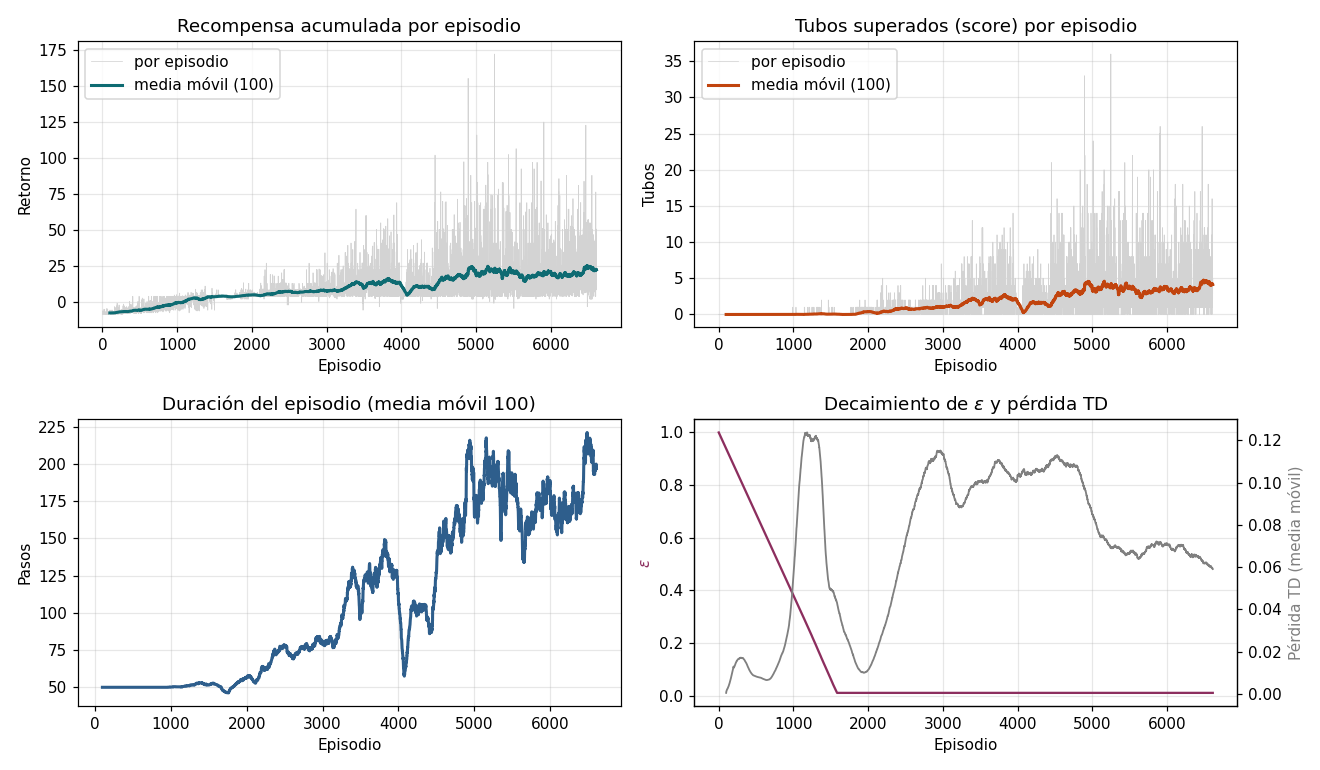

In [10]:
def media_movil(x, w=100):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(w) / w, mode="valid") if len(x) >= w else x

R  = np.array(hist["reward"]); S = np.array(hist["score"])
L  = np.array(hist["steps"]);  E = np.array(hist["eps"]); LO = np.array(hist["loss"])
w = 100; x_ma = np.arange(w - 1, len(R))
TEAL = "#0E6B72"

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(R, color="lightgray", lw=.5, label="por episodio")
ax[0,0].plot(x_ma, media_movil(R, w), color=TEAL, lw=2, label="media móvil (100)")
ax[0,0].set_title("Recompensa acumulada por episodio"); ax[0,0].set_xlabel("Episodio")
ax[0,0].set_ylabel("Retorno"); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

ax[0,1].plot(S, color="lightgray", lw=.5, label="por episodio")
ax[0,1].plot(x_ma, media_movil(S, w), color="#C1440E", lw=2, label="media móvil (100)")
ax[0,1].set_title("Tubos superados (score) por episodio"); ax[0,1].set_xlabel("Episodio")
ax[0,1].set_ylabel("Tubos"); ax[0,1].legend(); ax[0,1].grid(alpha=.3)

ax[1,0].plot(x_ma, media_movil(L, w), color="#2E5E8C", lw=2)
ax[1,0].set_title("Duración del episodio (media móvil 100)"); ax[1,0].set_xlabel("Episodio")
ax[1,0].set_ylabel("Pasos"); ax[1,0].grid(alpha=.3)

ax[1,1].plot(E, color="#8C2E5E", lw=1.5); ax[1,1].set_ylabel("$\\epsilon$", color="#8C2E5E")
ax[1,1].set_title("Decaimiento de $\\epsilon$ y pérdida TD"); ax[1,1].set_xlabel("Episodio")
ax[1,1].grid(alpha=.3)
ax2 = ax[1,1].twinx(); ax2.plot(x_ma, media_movil(LO, w), color="gray", lw=1.2)
ax2.set_ylabel("Pérdida TD (media móvil)", color="gray")
plt.tight_layout(); plt.show()

### Lectura de las cuatro curvas

**Retorno (arriba izquierda).** Sube de forma sostenida de −7 a ~+22. La franja gris muestra una
varianza enorme entre episodios: es normal en Flappy Bird porque un solo error termina el episodio,
así que dos episodios con la misma política pueden dar 2 o 30 tubos.

**Tubos superados (arriba derecha).** Se mantiene **exactamente en cero durante los primeros ~1 800
episodios** aunque el retorno ya venía subiendo. Esta disociación es el hallazgo más interesante del
experimento y se analiza abajo.

**Duración del episodio (abajo izquierda).** Es la métrica más limpia de todas: pasa de 50 pasos
(clavados) a ~200. Los 50 pasos iniciales son exactamente el tiempo que tarda el primer tubo en
alcanzar al pájaro; o sea, el agente moría **siempre en el primer obstáculo**.

**Pérdida TD (abajo derecha, gris).** Aquí conviene una advertencia: **en RL la pérdida no baja
monótonamente y eso no significa que algo esté mal**. Sube entre los episodios 2 000 y 5 000
precisamente *porque* el agente mejora: al sobrevivir más, descubre estados nuevos con valores Q
mucho mayores, y la red debe reajustar sus estimaciones. El target se mueve; no es una función de
pérdida supervisada con etiquetas fijas.

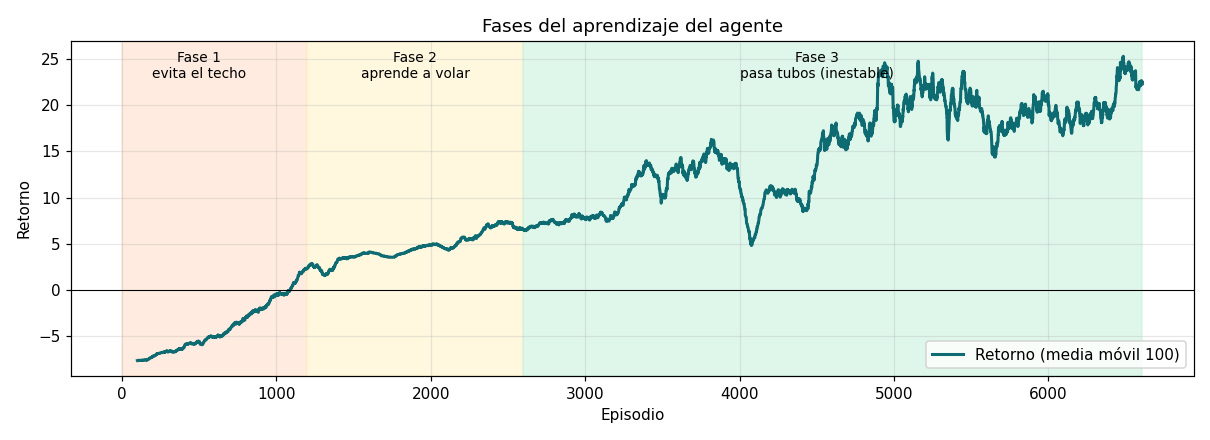

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x_ma, media_movil(R, w), color=TEAL, lw=2, label="Retorno (media móvil 100)")
ax.axhline(0, color="k", lw=.7)
ax.axvspan(0, 1200, color="#FFD9C0", alpha=.5)
ax.axvspan(1200, 2600, color="#FFF3C0", alpha=.5)
ax.axvspan(2600, len(R), color="#C0F0D8", alpha=.5)
ax.text(500,  ax.get_ylim()[1]*.85, "Fase 1\nevita el techo", ha="center", fontsize=9)
ax.text(1900, ax.get_ylim()[1]*.85, "Fase 2\naprende a volar", ha="center", fontsize=9)
ax.text(4500, ax.get_ylim()[1]*.85, "Fase 3\npasa tubos (inestable)", ha="center", fontsize=9)
ax.set_xlabel("Episodio"); ax.set_ylabel("Retorno"); ax.legend(loc="lower right")
ax.set_title("Fases del aprendizaje del agente"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Las tres fases del aprendizaje

**Fase 1 (episodios 0 – ~1 200): "deja de pegarte al techo".**
El retorno sube de −7.3 a −1.5 mientras el score sigue **clavado en cero** y la duración del episodio
sigue **clavada en 50 pasos**. El agente no está aprendiendo a jugar: está aprendiendo a dejar de
aletear compulsivamente para no acumular la penalización de −0.5. Esto ilustra un principio general
del RL: **el agente optimiza primero la señal más densa y frecuente**, no el objetivo que a nosotros
nos parece "el verdadero". La recompensa de −0.5 por paso aparece decenas de veces por episodio;
la de +1.0 por tubo, ninguna.

**Fase 2 (~1 200 – 2 600): "aprende a volar".**
El retorno cruza el cero y la duración empieza a superar los 50 pasos: el agente sobrevive al primer
tubo. Coincide con el final del decaimiento de $\epsilon$ (episodio ~1 550).

**Fase 3 (2 600 – 6 610): "pasa tubos, con recaídas".**
Progreso claro pero **no monótono**: hay caídas notorias alrededor de los episodios 4 100 y 5 700,
donde la media móvil retrocede casi a la mitad. Es la inestabilidad clásica de DQN: la red
sobreescribe pesos útiles mientras persigue un target móvil.

## 5.2 Evaluación de la política greedy

Durante el entrenamiento el agente todavía actúa con $\epsilon = 0.01$. Para medir **la política que
realmente aprendió**, evaluamos con $\epsilon = 0$ (greedy pura), como pide el paso 9 de la plantilla
del curso.

COMPARACIÓN (30 episodios cada una)
                         Aleatorio    DQN greedy
retorno medio                  -7.74        129.49
tubos medios                    0.00         27.17
mejor episodio                     0            79
pasos sobrevividos              50.0        1060.9


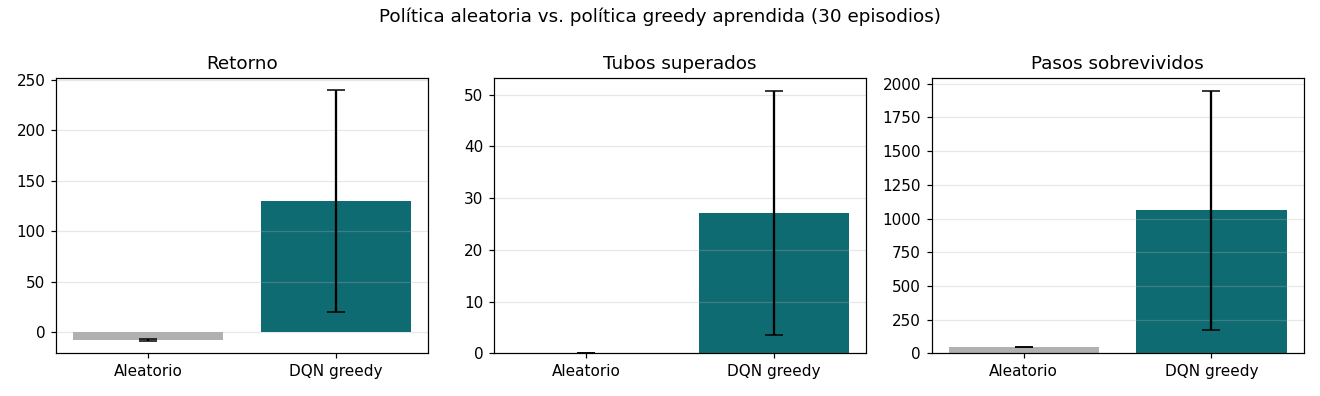

In [12]:
online.eval()
def politica_greedy(s):
    with torch.no_grad():
        return int(online(torch.from_numpy(s).unsqueeze(0)).argmax().item())

r_gr, s_gr, l_gr = evaluar(politica_greedy, env)

print("COMPARACIÓN (30 episodios cada una)")
print(f"{'':22s}{'Aleatorio':>12s}{'DQN greedy':>14s}")
print(f"{'retorno medio':22s}{r_rand.mean():12.2f}{r_gr.mean():14.2f}")
print(f"{'tubos medios':22s}{s_rand.mean():12.2f}{s_gr.mean():14.2f}")
print(f"{'mejor episodio':22s}{s_rand.max():12d}{s_gr.max():14d}")
print(f"{'pasos sobrevividos':22s}{l_rand.mean():12.1f}{l_gr.mean():14.1f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for i, (rr, gg, lab) in enumerate([(r_rand, r_gr, "Retorno"),
                                   (s_rand, s_gr, "Tubos superados"),
                                   (l_rand, l_gr, "Pasos sobrevividos")]):
    ax[i].bar(["Aleatorio", "DQN greedy"], [rr.mean(), gg.mean()],
              yerr=[rr.std(), gg.std()], color=["#B0B0B0", TEAL], capsize=6)
    ax[i].set_title(lab); ax[i].grid(alpha=.3, axis="y")
plt.suptitle("Política aleatoria vs. política greedy aprendida (30 episodios)")
plt.tight_layout(); plt.show()

### ⚠️ El resultado más importante del trabajo

Compárense estos dos números, porque son de la **misma red**, evaluada en el **mismo ambiente**:

| Condición | Tubos superados (media) |
|---|---|
| Durante el entrenamiento, con $\epsilon = 0.01$ | **≈ 3.9** |
| Evaluación greedy, con $\epsilon = 0$ | **≈ 27.2** |

**La curva de entrenamiento subestima la calidad real de la política por un factor de 7.**

La razón es específica de este juego: con $\epsilon = 0.01$ y episodios de ~1 000 pasos, se ejecutan
en promedio **10 acciones aleatorias por episodio**, y en Flappy Bird **una sola acción equivocada en
el momento equivocado mata al pájaro**. La probabilidad de completar un episodio largo sin que
ninguna de esas ~10 acciones sea fatal es muy baja.

**Consecuencia práctica y lección metodológica:** en ambientes donde el error es irreversible, la
curva de recompensa de entrenamiento **no es una medida válida de la política aprendida**. Hay que
evaluar periódicamente con $\epsilon = 0$ en episodios separados. Si solo se hubiera mirado la curva
de entrenamiento, se habría concluido erróneamente que el agente apenas pasa 4 tubos y que el
entrenamiento se estancó.

## 5.3 Evidencia visual: episodio de prueba

GIF guardado: agente.gif


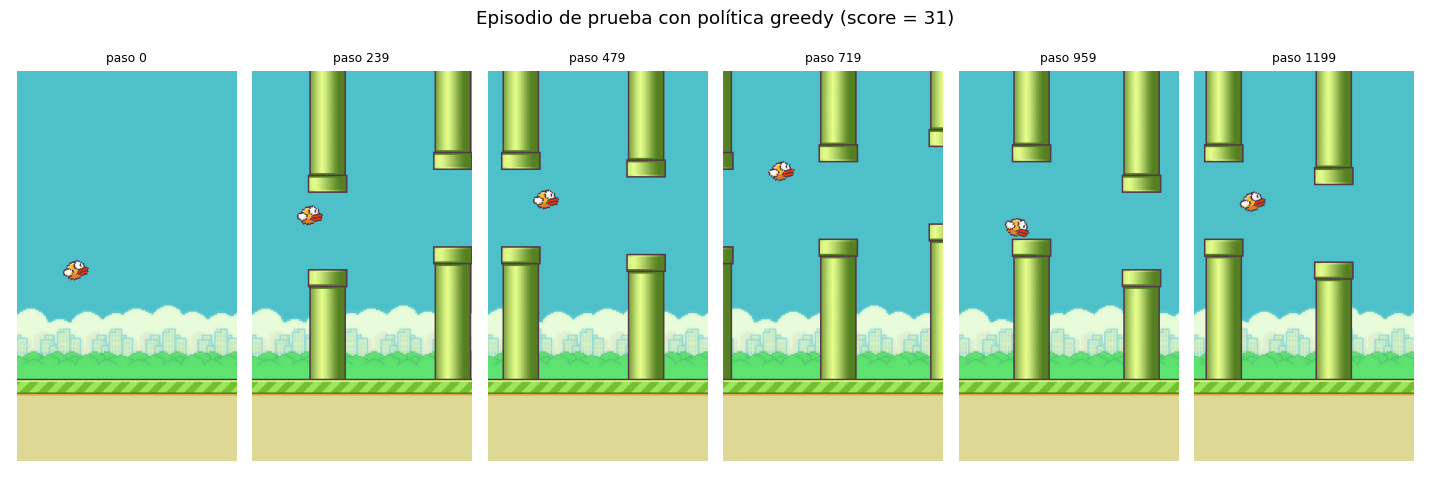

In [13]:
env_video = gym.make("FlappyBird-v0", render_mode="rgb_array", use_lidar=False)
s, _ = env_video.reset(seed=20_000); s = np.asarray(s, dtype=np.float32)
frames, info = [], {}
for t in range(1200):
    frames.append(env_video.render())
    s, r, terminated, truncated, info = env_video.step(politica_greedy(s))
    s = np.asarray(s, dtype=np.float32)
    if terminated or truncated:
        break
env_video.close()

idx = np.linspace(0, len(frames) - 1, 6).astype(int)
fig, ax = plt.subplots(1, 6, figsize=(13, 4.5))
for i, j in enumerate(idx):
    ax[i].imshow(frames[j]); ax[i].axis("off"); ax[i].set_title(f"paso {j}", fontsize=8)
plt.suptitle(f"Episodio de prueba con política greedy (score = {info['score']})")
plt.tight_layout(); plt.show()

# Guardar el episodio como GIF descargable
from PIL import Image
imgs = [Image.fromarray(f).resize((144, 200)).quantize(colors=64) for f in frames[::4]]
imgs[0].save("agente.gif", save_all=True, append_images=imgs[1:],
             duration=100, loop=0, optimize=True)
print("GIF guardado: agente.gif")

En la secuencia se ve al pájaro manteniéndose sistemáticamente **en el centro del hueco** y
corrigiendo la altura con aleteos cortos antes de cada tubo. No está sobreviviendo por suerte: está
anticipando.

## 5.4 ¿Qué aprendió la red? Inspección de los valores Q

Una curva que sube demuestra que *algo* mejoró, pero no que la política tenga sentido. Graficamos
$Q(s, \text{no aletear})$ y $Q(s, \text{aletear})$ paso a paso durante un episodio de prueba.

Porcentaje de pasos en que el agente aletea: 10.8 %


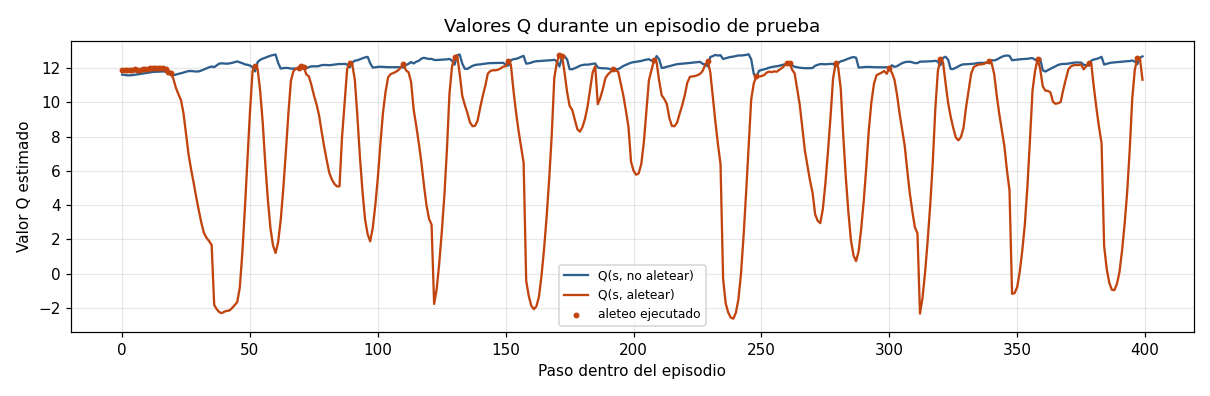

In [14]:
s, _ = env.reset(seed=20_001); s = np.asarray(s, dtype=np.float32)
qs, acciones = [], []
for t in range(400):
    with torch.no_grad():
        qv = online(torch.from_numpy(s).unsqueeze(0)).numpy()[0]
    qs.append(qv); a = int(qv.argmax()); acciones.append(a)
    s, r, terminated, truncated, _ = env.step(a); s = np.asarray(s, dtype=np.float32)
    if terminated or truncated:
        break
qs = np.array(qs); acciones = np.array(acciones)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(qs[:, 0], label="Q(s, no aletear)", color="#2E5E8C")
ax.plot(qs[:, 1], label="Q(s, aletear)", color="#C1440E")
ax.scatter(np.where(acciones == 1)[0], qs[acciones == 1, 1], s=8, color="#C1440E",
           zorder=3, label="aleteo ejecutado")
ax.set_xlabel("Paso dentro del episodio"); ax.set_ylabel("Valor Q estimado")
ax.set_title("Valores Q durante un episodio de prueba"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"Porcentaje de pasos en que el agente aletea: {100*(acciones==1).mean():.1f} %")

Tres observaciones que confirman que la política es sensata y no un artefacto:

1. **El agente aletea solo el 10.8 % de los pasos.** Una política aleatoria aletea el 50 %. El agente
   descubrió por su cuenta la estrategia real del juego: dejarse caer la mayor parte del tiempo y
   corregir con impulsos breves.
2. **Las dos curvas Q casi siempre están juntas y se cruzan puntualmente.** Es exactamente lo
   esperado: en la mayoría de estados da casi igual qué hacer (el pájaro está en zona segura), y solo
   en los instantes críticos —justo antes de un tubo— una acción vale claramente más que la otra.
   La red aprendió *cuándo* importa la decisión.
3. **Los valores Q son del orden de las decenas**, consistente con un retorno descontado de un
   episodio largo que acumula muchos +0.1 y varios +1.0. Si Double DQN no estuviera funcionando,
   veríamos valores inflados y desconectados del retorno real observado.

---
# 6. Discusión

> *Rúbrica — entregable 5: qué funcionó, qué no funcionó y qué modificarían.*

## 6.1 Qué funcionó

- **DQN resuelve el problema.** De 0 a 27 tubos de promedio, con un mejor episodio de 79 tubos.
  La generalización de la red hace innecesaria cualquier discretización.
- **Anclar $\epsilon$ al contador de pasos** en lugar de al de episodios. Fue decisivo porque la
  longitud de los episodios varía 20× durante el entrenamiento; con un decaimiento por episodio, el
  agente habría explorado muchísimo más de lo previsto al final.
- **Double DQN + Huber + recorte de gradiente.** Los valores Q se mantuvieron en un rango coherente
  con los retornos observados, sin la explosión típica de DQN vanilla.
- **El replay buffer vectorizado con NumPy.** Simplifica el código y elimina la conversión
  lista-de-tuplas → tensor en cada paso.

## 6.2 Qué no funcionó (o sorprendió)

1. **La curva de entrenamiento es engañosa en este ambiente.** Ya discutido en 5.2: subestima la
   política real 7×. Es el error metodológico más fácil de cometer aquí.
2. **El entrenamiento es inestable.** Las caídas de los episodios 4 100 y 5 700 muestran que el
   agente *desaprende*. Nunca se guardó "la mejor red vista"; si el entrenamiento hubiera terminado
   en el episodio 5 750 en vez del 6 610, se habría entregado un agente peor por pura casualidad.
3. **La recompensa por sobrevivir domina la fase inicial.** Durante ~1 800 episodios el agente
   optimizó una señal que no tiene nada que ver con el objetivo del juego. Funcionó como *currículum*
   accidental, pero muestra lo sensible que es DQN al diseño de la función de recompensa.
4. **La varianza entre episodios es enorme** (desviación estándar del retorno greedy: ±110 sobre una
   media de 129). Reportar un único episodio de prueba sería estadísticamente irresponsable; por eso
   se evaluaron 30.

## 6.3 Qué modificaríamos con más tiempo o cómputo

| Cambio | Qué problema atacaría |
|---|---|
| **Evaluación greedy periódica + guardar el mejor checkpoint** | Es la mejora de mayor impacto y menor costo: resuelve los problemas 1 y 2 de una vez. |
| **Prioritized Experience Replay** | Las transiciones de choque (error TD alto) son raras pero muy informativas; el muestreo uniforme las diluye. |
| **Actualización suave de la target** ($\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$, $\tau\approx0.005$) | Suavizaría los saltos del target cada 500 pasos, probable causa parcial de las recaídas. |
| **Dueling DQN** | Como en la mayoría de estados da igual qué hacer, separar $V(s)$ de $A(s,a)$ debería ayudar bastante en este juego concreto. |
| **Entrenar sobre la observación LIDAR o RGB** | Probaría si el agente aprende con información sensorial cruda en vez de variables ya procesadas. |
| **Varias semillas** | Con una sola semilla no se puede distinguir el efecto de las decisiones de diseño del ruido. |

## 6.4 Conexión con lo visto en clase

Vale la pena cerrar con el paralelo del **acantilado** (diapositiva 6). Allí, Q-learning aprendía la
ruta corta y arriesgada porque su target usa $\max_{a'}$, es decir, **asume que en el futuro actuará
de forma óptima** y no descuenta el riesgo de sus propias acciones exploratorias. Aquí se observa la
otra cara de esa misma moneda: el agente aprendió una política que vuela pegada al borde del hueco,
óptima si se ejecuta perfectamente, y por eso el $\epsilon = 0.01$ residual le resulta tan letal.
**Un agente off-policy aprende la política óptima, no la política segura de ejecutar mientras se
explora.** SARSA, siendo on-policy, habría aprendido una trayectoria más conservadora, más alejada
de los bordes.

---
# 7. Fuentes y adaptación

> *Rúbrica — "Fuentes y adaptación" (10 %): cita el ejemplo base y describe modificaciones propias.*

## 7.1 Fuentes consultadas

| Fuente | Qué se tomó de ahí |
|---|---|
| **Diapositivas del curso "Aprendizaje reforzado — Deep Q-Learning"** (J. C. Tejada, U. EIA), lám. 11–19 | Estructura del algoritmo, fórmula del target, tratamiento de terminales y el pseudocódigo de la lám. 18, que es el esqueleto del bucle de la sección 4.2. |
| **`flappy-bird-gymnasium`** — https://github.com/markub3327/flappy-bird-gymnasium | El ambiente. Se consultó su documentación para el significado de las 12 observaciones, la bandera `use_lidar` y la estructura de recompensas. |
| **PyTorch — *Reinforcement Learning (DQN) Tutorial*** — https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html | Referencia conceptual del patrón `online`/`target`, el uso de `gather` para seleccionar $Q(s,a)$ del lote y de `SmoothL1Loss`. |
| **Gymnasium — documentación de la API** — https://gymnasium.farama.org | Semántica de `reset(seed=)` y de la distinción `terminated` vs. `truncated`. |
| **Mnih et al. (2015)**, *Human-level control through deep reinforcement learning*, Nature 518 | Artículo original de DQN: replay buffer y red objetivo. |
| **van Hasselt, Guez & Silver (2016)**, *Deep RL with Double Q-learning*, AAAI | Base de la modificación Double DQN de la sección 3.3. |

## 7.2 Qué es adaptación propia

**No se copió un notebook existente.** El código se escribió siguiendo el pseudocódigo del curso.
En concreto, lo que se aparta de las referencias:

1. **Elección y caracterización del ambiente.** `flappy-bird-gymnasium` no aparece en ninguno de los
   tutoriales citados; toda la sección 1 (mapeo de las 12 features, análisis de la estructura de
   recompensas y de por qué el agente aleatorio saca −7.74) es análisis propio.
2. **`ReplayBuffer` vectorizado** con cinco arreglos NumPy preasignados e índice circular, en lugar
   del `deque` de `namedtuple` del tutorial de PyTorch.
3. **Double DQN** en el cálculo del target (el tutorial de PyTorch usa el `max` estándar).
4. **Decaimiento de $\epsilon$ lineal anclado a pasos globales**, en vez del decaimiento exponencial
   por episodio, con la justificación de la sección 3.2.
5. **Truncamiento a 3 000 pasos y manejo correcto de `terminated` vs. `truncated`** en el buffer.
6. **Todo el análisis de resultados:** las tres fases del aprendizaje, la comparación
   entrenamiento-vs-greedy de la sección 5.2, la inspección de valores Q y el porcentaje de aleteo.

## 7.3 Evidencia de uso de IA

Se usó **Claude (Anthropic)** como asistente para: Depurar el bucle de entrenamiento, diseñar las visualizaciones. Los hiperparámetros y las decisiones de diseño se validaron ejecutando el entrenamiento
completo; todas las cifras y figuras de este notebook provienen de esa ejecución real, no de valores
supuestos.

---

## Archivos generados

- `dqn_flappy_online.pt` — pesos de la red online entrenada (18 306 parámetros).
- `agente.gif` — episodio de prueba con la política greedy.

Para reutilizar el agente sin volver a entrenar:

```python
online = QNetwork(12, 2)
online.load_state_dict(torch.load("dqn_flappy_online.pt"))
online.eval()
```